In [2]:
!pip install ydata-profiling seaborn matplotlib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


In [3]:
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("Loan_default.csv")

# Basic info
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
df.head()


Shape: (255347, 18)

Data Types:
 LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


Missing Values:
 Series([], dtype: int64)


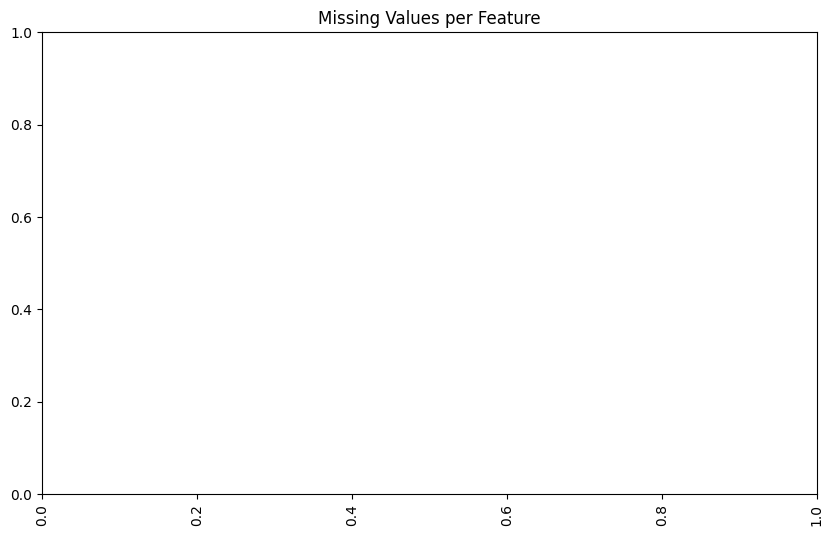

In [4]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Missing Values:\n", missing)


In [5]:
# Summary statistics
desc = df.describe(include="all").T
print(desc[["mean", "50%", "std"]])  # mean, median (50%), std

# Mode separately (since describe skips it sometimes)
modes = df.mode().iloc[0]
print("\nMode of each column:\n", modes)

# Skewness
skewness = df.skew(numeric_only=True)
print("\nSkewness of numerical features:\n", skewness)


                         mean       50%           std
LoanID                    NaN       NaN           NaN
Age                 43.498306      43.0     14.990258
Income           82499.304597   82466.0  38963.013729
LoanAmount      127578.865512  127556.0  70840.706142
CreditScore        574.264346     574.0    158.903867
MonthsEmployed      59.541976      60.0     34.643376
NumCreditLines       2.501036       2.0      1.117018
InterestRate        13.492773     13.46      6.636443
LoanTerm            36.025894      36.0      16.96933
DTIRatio             0.500212       0.5      0.230917
Education                 NaN       NaN           NaN
EmploymentType            NaN       NaN           NaN
MaritalStatus             NaN       NaN           NaN
HasMortgage               NaN       NaN           NaN
HasDependents             NaN       NaN           NaN
LoanPurpose               NaN       NaN           NaN
HasCoSigner               NaN       NaN           NaN
Default              0.11612

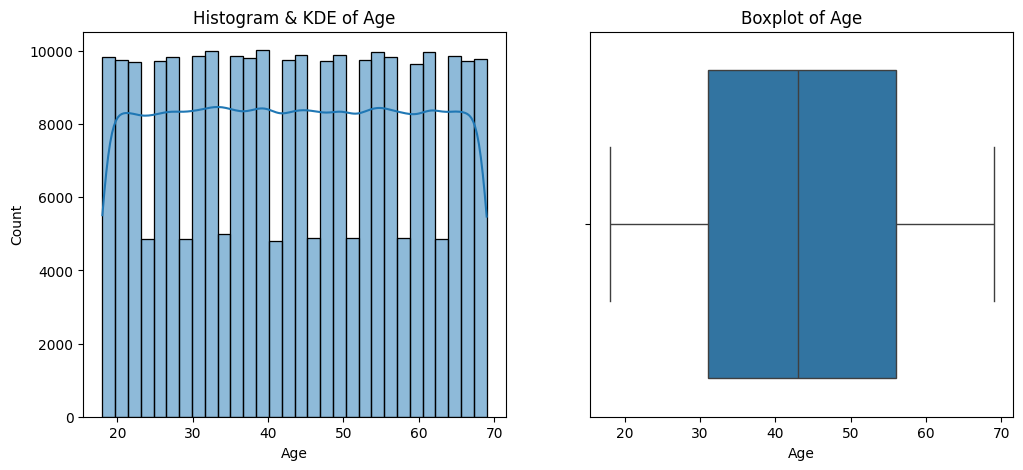

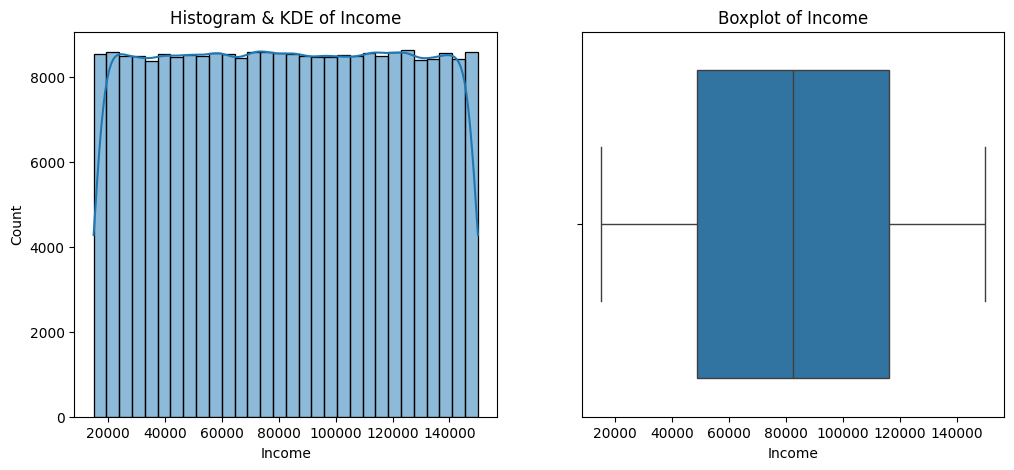

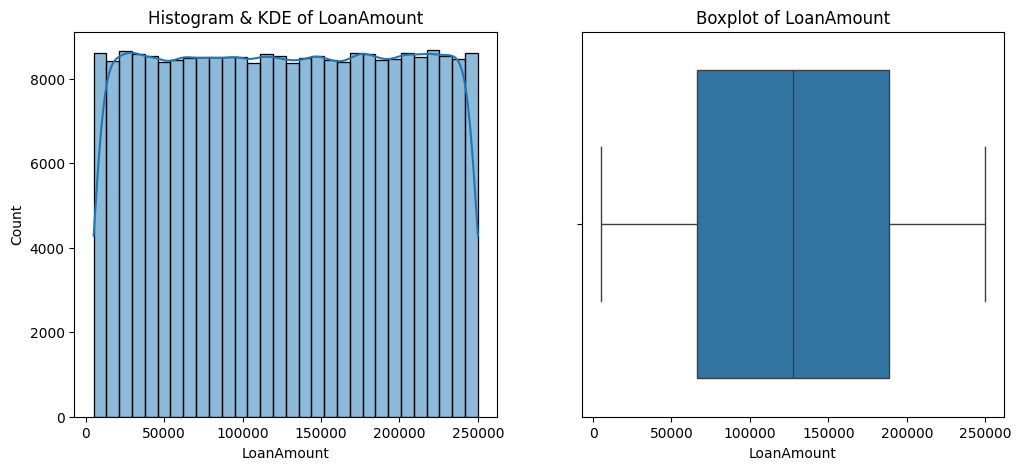

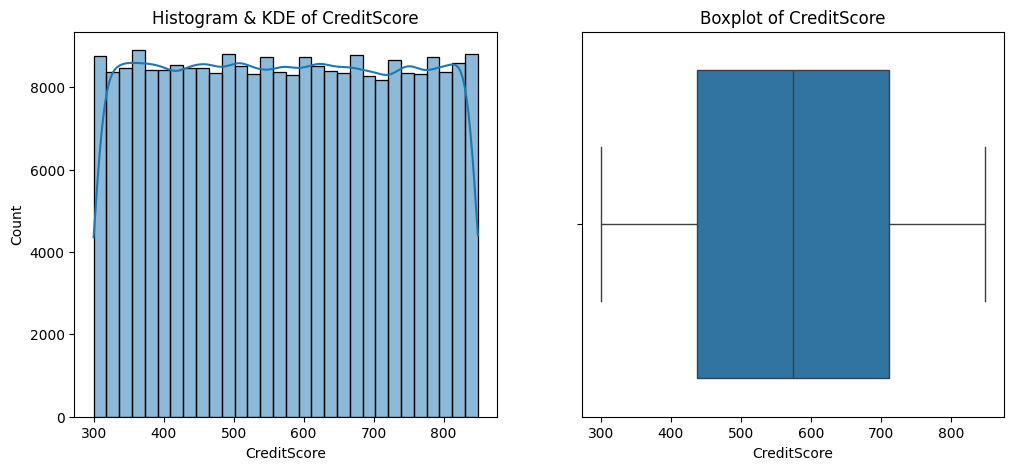

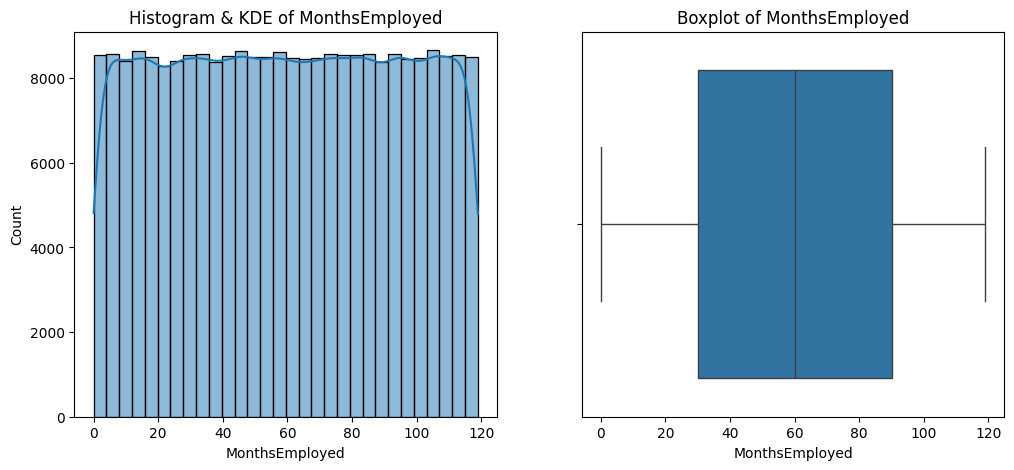

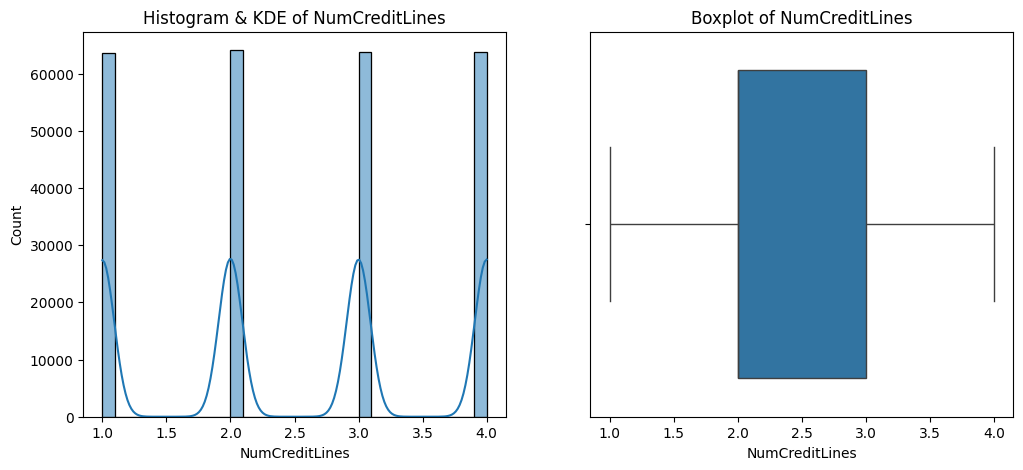

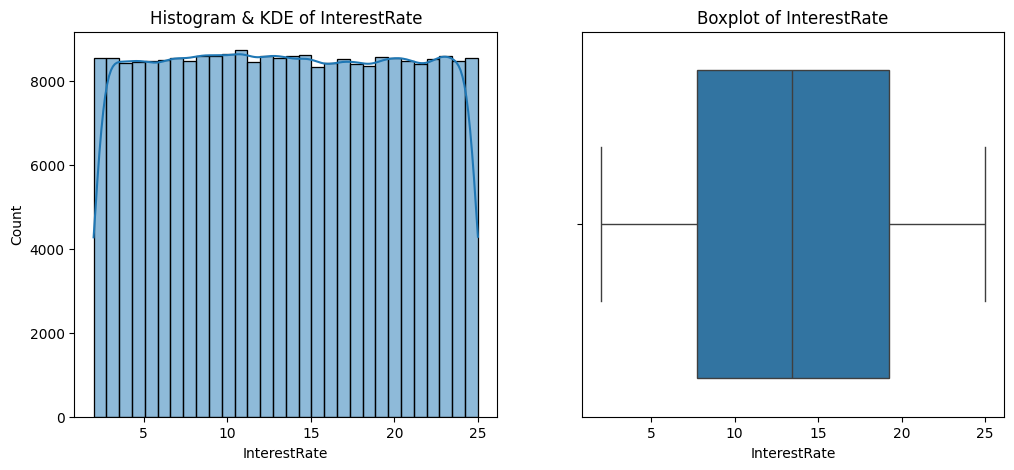

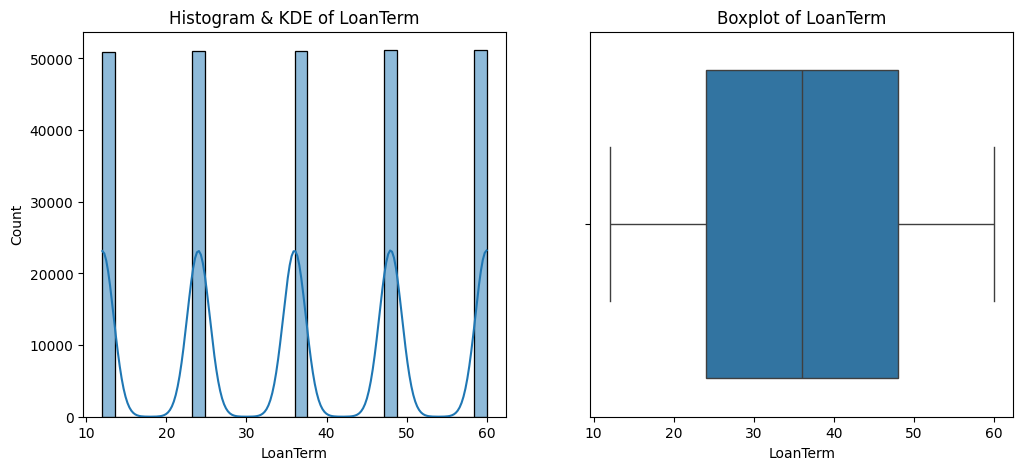

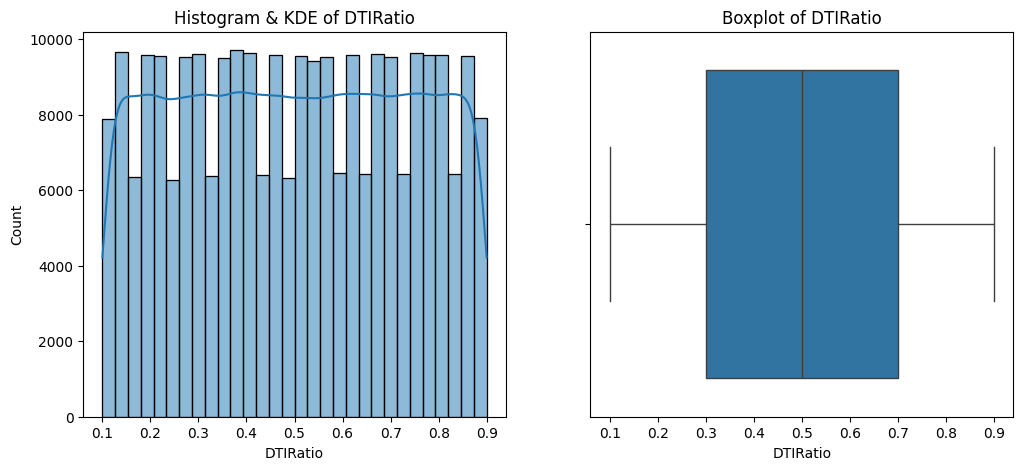

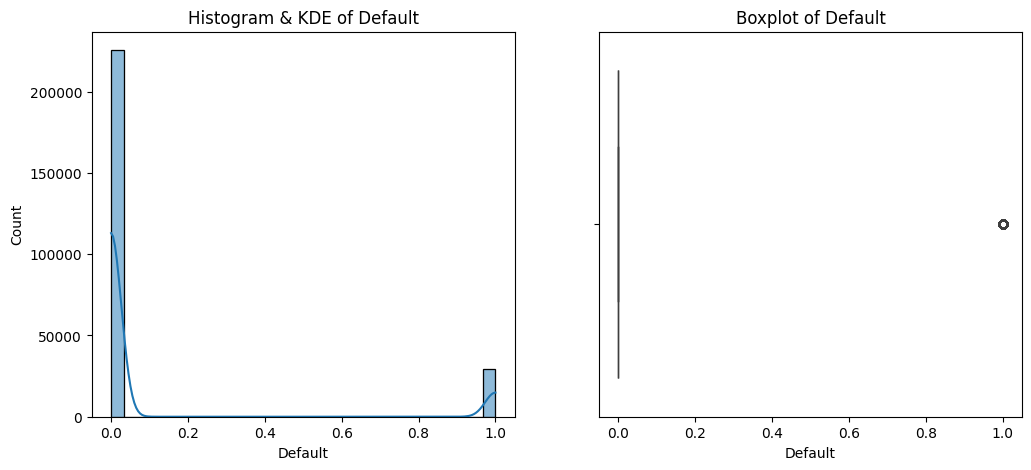

In [6]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(12,5))

    # Histogram + KDE
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Histogram & KDE of {col}")

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

    plt.show()


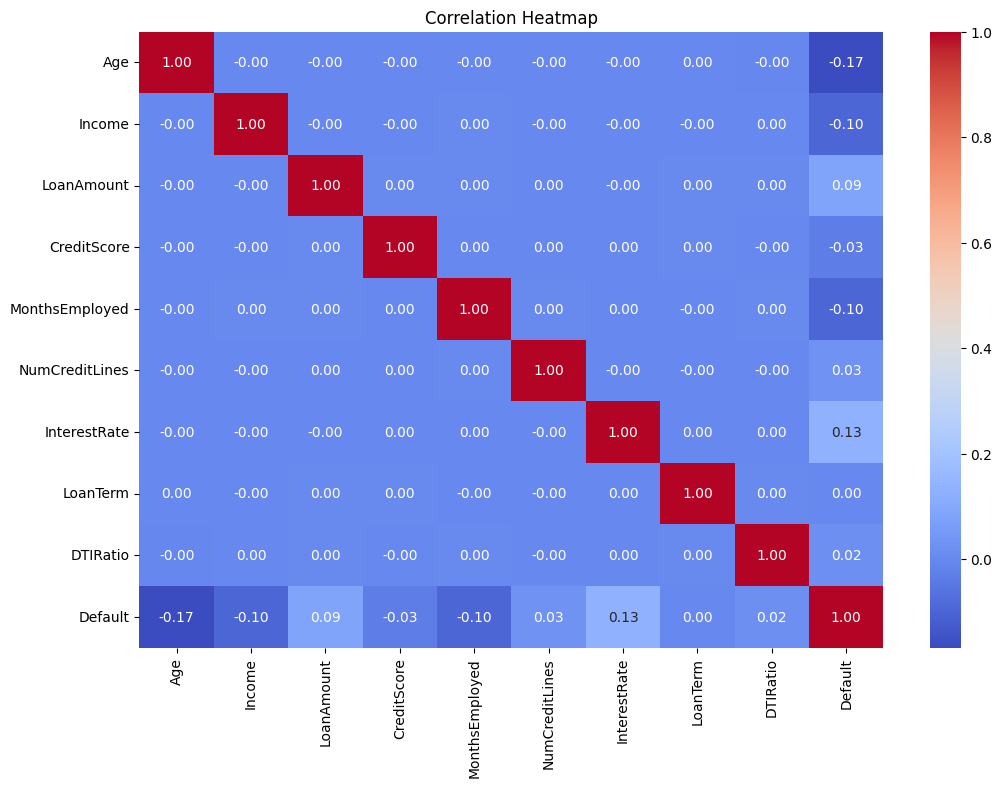


Covariance matrix:
                         Age        Income    LoanAmount   CreditScore  \
Age              224.707847 -7.266333e+02 -2.349755e+03     -1.305749   
Income          -726.633252  1.518116e+09 -2.388444e+06  -8856.434459   
LoanAmount     -2349.755323 -2.388444e+06  5.018406e+09  14197.937653   
CreditScore       -1.305749 -8.856434e+03  1.419794e+04  25250.438819   
MonthsEmployed    -0.177287  3.610577e+03  6.912970e+03      3.373593   
NumCreditLines    -0.014899 -8.775894e+01  6.286151e+01      0.002847   
InterestRate      -0.112154 -5.956101e+02 -1.077125e+03      0.459933   
LoanTerm           0.066988 -6.599837e+02  3.050938e+03      3.048022   
DTIRatio          -0.016232  1.848896e+00  1.836089e+01     -0.038134   
Default           -0.805790 -1.237303e+03  1.966808e+03     -1.739399   

                MonthsEmployed  NumCreditLines  InterestRate     LoanTerm  \
Age                  -0.177287       -0.014899     -0.112154     0.066988   
Income             36

In [7]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Covariance
covariance = df.cov(numeric_only=True)
print("\nCovariance matrix:\n", covariance)


In [8]:
# Using IQR method
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]

    print(f"{col}: {len(outliers)} outliers")


Age: 0 outliers
Income: 0 outliers
LoanAmount: 0 outliers
CreditScore: 0 outliers
MonthsEmployed: 0 outliers
NumCreditLines: 0 outliers
InterestRate: 0 outliers
LoanTerm: 0 outliers
DTIRatio: 0 outliers
Default: 29653 outliers


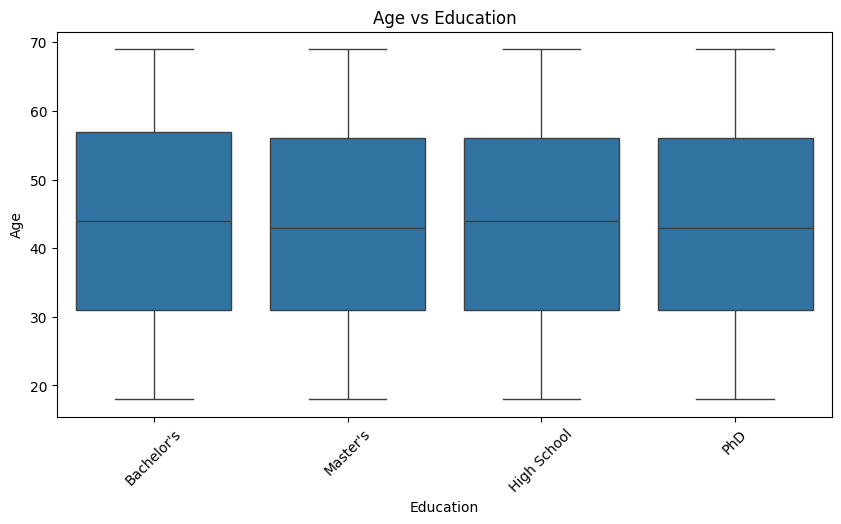

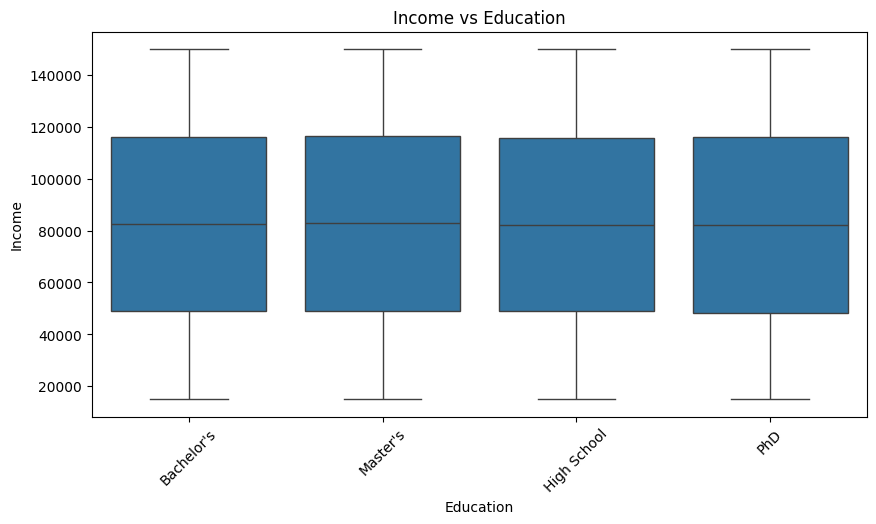

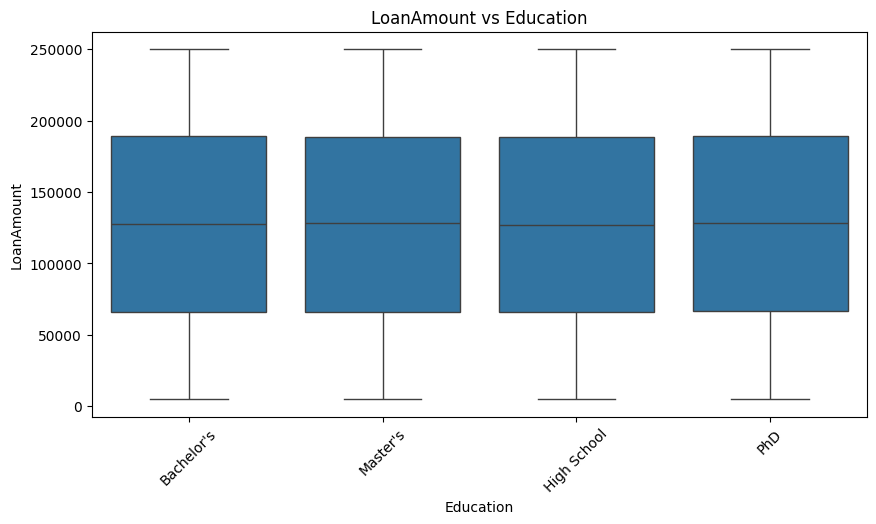

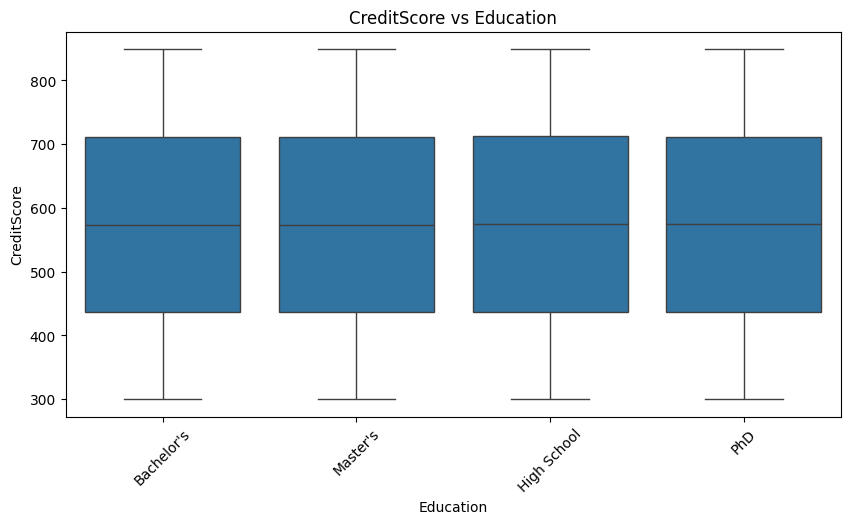

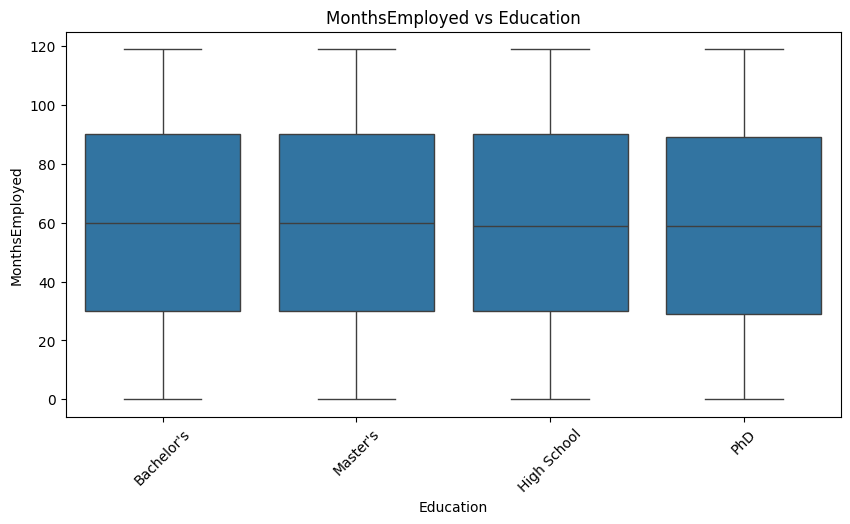

In [11]:
# Select categorical columns with reasonable unique values (< 20 categories)
cat_cols = [col for col in df.select_dtypes(exclude=np.number).columns if df[col].nunique() < 20]

# Ensure numeric columns are clean
num_cols = df.select_dtypes(include=np.number).columns

plot_count = 0
for cat in cat_cols:
    for num in num_cols:
        plt.figure(figsize=(10,5))
        sns.boxplot(x=df[cat], y=df[num], data=df)
        plt.title(f"{num} vs {cat}")
        plt.xticks(rotation=45)
        plt.show()

        plot_count += 1
        if plot_count >= 5:
            break
    if plot_count >= 5:
        break
